In [1]:
import numpy as np
import pandas as pd
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [2]:
# ── PATHS (update these) ──────────────────────────────────
TRAIN_PATH  = r"C:\Users\aryan\Downloads\Dataset for satellite anomaly\data\data\train"
TEST_PATH   = r"C:\Users\aryan\Downloads\Dataset for satellite anomaly\data\data\test"
LABELS_PATH = r"C:\Users\aryan\Downloads\labeled_anomalies.csv"
OPS_PATH    = r"C:\Users\aryan\Downloads\dataset.csv"   # OPS-SAT
# ──────────────────────────────────────────────────────────

labels_df = pd.read_csv(LABELS_PATH)
print(f"Labeled channels: {len(labels_df)}")
print(labels_df[['chan_id','spacecraft','class']].head(6).to_string())

Labeled channels: 82
  chan_id spacecraft                                 class
0     P-1       SMAP  [contextual, contextual, contextual]
1     S-1       SMAP                               [point]
2     E-1       SMAP              [contextual, contextual]
3     E-2       SMAP                               [point]
4     E-3       SMAP                               [point]
5     E-4       SMAP                               [point]


In [3]:
def load_npy_folder(folder, max_channels=30):
    """Load .npy files, trim to same length, stack."""
    signals = []
    names   = []
    for f in sorted(os.listdir(folder)):
        if f.endswith('.npy'):
            s = np.load(os.path.join(folder, f))
            if s.ndim == 2: s = s[:, 0]   # take first col if 2D
            signals.append(s)
            names.append(f.replace('.npy',''))
        if len(signals) >= max_channels:
            break

    min_len = min(len(s) for s in signals)
    data    = np.stack([s[:min_len] for s in signals], axis=1)
    return data, names

train_raw, channel_names = load_npy_folder(TRAIN_PATH)
test_raw,  _             = load_npy_folder(TEST_PATH)

print(f"Train: {train_raw.shape}   Test: {test_raw.shape}")
print(f"Channels loaded: {channel_names[:5]} ...")

# Normalize using train stats only
scaler      = StandardScaler()
train_scaled = scaler.fit_transform(train_raw)
test_scaled  = scaler.transform(test_raw)

Train: (312, 30)   Test: (2051, 30)
Channels loaded: ['A-1', 'A-2', 'A-3', 'A-4', 'A-5'] ...


In [4]:
def get_anomaly_mask(labels_df, channel_id, total_len):
    """Build binary mask for a channel's anomaly windows."""
    mask = np.zeros(total_len, dtype=int)
    row  = labels_df[labels_df['chan_id'] == channel_id]
    if row.empty:
        return mask
    seqs = eval(row.iloc[0]['anomaly_sequences'])
    for start, end in seqs:
        mask[start:end+1] = 1
    return mask

# Build mask for all test channels we loaded
# Use first channel that has labels as demo
demo_chan = labels_df['chan_id'].iloc[0]   # e.g. P-1
test_mask = get_anomaly_mask(labels_df, demo_chan, len(test_scaled))
print(f"Channel '{demo_chan}': {test_mask.sum()} labeled anomaly timestamps")

Channel 'P-1': 0 labeled anomaly timestamps


In [5]:
def make_windows(data, seq_len=64, stride=1):
    X = []
    for i in range(0, len(data) - seq_len, stride):
        X.append(data[i : i + seq_len])
    return np.array(X, dtype=np.float32)

SEQ_LEN = 64
STRIDE  = 4    # stride > 1 = faster, still good coverage

X_train = make_windows(train_scaled, SEQ_LEN, STRIDE)
X_test  = make_windows(test_scaled,  SEQ_LEN, stride=1)

print(f"Train windows: {X_train.shape}")
print(f"Test  windows: {X_test.shape}")

X_train_t = torch.tensor(X_train).to(device)
X_test_t  = torch.tensor(X_test).to(device)

train_loader = DataLoader(
    TensorDataset(X_train_t),
    batch_size=128, shuffle=True
)

Train windows: (62, 64, 30)
Test  windows: (1987, 64, 30)


In [6]:
def augment(x):
    """
    Paper-faithful augmentations:
      Gaussian Jitter  → sensor degradation / thermal noise
      Time Warping     → clock drift (implemented as roll)
      Channel Masking  → intermittent sensor failure
    """
    aug = x.clone()
    choice = torch.randint(0, 3, (1,)).item()

    if choice == 0:   # Gaussian jitter
        aug = aug + torch.randn_like(aug) * 0.05

    elif choice == 1: # Time warping (roll shift)
        shift = torch.randint(1, 8, (1,)).item()
        aug = torch.roll(aug, shifts=shift, dims=1)

    else:             # Channel masking (10% channels zeroed)
        n_mask = max(1, aug.shape[-1] // 10)
        idx    = torch.randperm(aug.shape[-1])[:n_mask]
        aug[:, :, idx] = 0.0

    return aug

In [7]:
class SharedEncoder(nn.Module):
    """
    Shared encoder f_θ from paper.
    Maps (batch, seq_len, features) → (batch, embed_dim)
    """
    def __init__(self, input_dim, embed_dim=128):
        super().__init__()
        # 1D CNN encoder for sequence → embedding
        self.conv1 = nn.Conv1d(input_dim, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.pool  = nn.AdaptiveAvgPool1d(1)
        self.proj  = nn.Linear(128, embed_dim)
        self.bn    = nn.BatchNorm1d(embed_dim)

    def forward(self, x):
        # x: (B, T, C) → (B, C, T) for conv
        x = x.permute(0, 2, 1)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x).squeeze(-1)   # (B, 128)
        x = self.bn(self.proj(x))
        return x


class ProjectionHead(nn.Module):
    """
    MLP projection head g_φ from paper.
    Maps embedding → lower-dim latent z_i
    """
    def __init__(self, embed_dim=128, proj_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, proj_dim)
        )

    def forward(self, h):
        z = self.net(h)
        return F.normalize(z, dim=1)   # unit sphere

In [8]:
def nt_xent_loss(z1, z2, temperature=0.1):
    """
    Normalized Temperature-scaled Cross-Entropy (NT-Xent).
    Exact loss from paper Section III-B.
    z1, z2: (N, proj_dim) — two augmented views
    """
    N  = z1.shape[0]
    z  = torch.cat([z1, z2], dim=0)   # (2N, proj_dim)

    # cosine similarity matrix
    sim = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=2)
    sim = sim / temperature

    # mask self-similarity on diagonal
    mask = torch.eye(2 * N, dtype=torch.bool, device=z.device)
    sim.masked_fill_(mask, -9e15)

    # positive pairs: (i, i+N) and (i+N, i)
    labels = torch.cat([torch.arange(N, 2*N),
                        torch.arange(0,  N)]).to(z.device)

    return F.cross_entropy(sim, labels)

In [9]:
encoder    = SharedEncoder(input_dim=X_train.shape[2]).to(device)
proj_head  = ProjectionHead().to(device)

optimizer  = torch.optim.AdamW(
    list(encoder.parameters()) + list(proj_head.parameters()),
    lr=1e-3, weight_decay=1e-4
)

PRETRAIN_EPOCHS = 15   # paper says 100 — use 15 for speed, still meaningful

print("=== Contrastive Pretraining ===")
encoder.train(); proj_head.train()

for epoch in range(PRETRAIN_EPOCHS):
    total_loss = 0
    for (batch,) in train_loader:
        v1 = augment(batch)
        v2 = augment(batch)

        h1 = encoder(v1);  z1 = proj_head(h1)
        h2 = encoder(v2);  z2 = proj_head(h2)

        loss = nt_xent_loss(z1, z2, temperature=0.1)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1:02d}/{PRETRAIN_EPOCHS}  "
          f"NT-Xent Loss: {total_loss/len(train_loader):.4f}")

torch.save(encoder.state_dict(), 'encoder_pretrained.pt')
print("Encoder saved.")

=== Contrastive Pretraining ===
Epoch 01/15  NT-Xent Loss: 2.0072
Epoch 02/15  NT-Xent Loss: 3.0302
Epoch 03/15  NT-Xent Loss: 1.7775
Epoch 04/15  NT-Xent Loss: 1.6621
Epoch 05/15  NT-Xent Loss: 1.5864
Epoch 06/15  NT-Xent Loss: 1.5637
Epoch 07/15  NT-Xent Loss: 1.4134
Epoch 08/15  NT-Xent Loss: 1.3605
Epoch 09/15  NT-Xent Loss: 1.2788
Epoch 10/15  NT-Xent Loss: 1.2026
Epoch 11/15  NT-Xent Loss: 1.1333
Epoch 12/15  NT-Xent Loss: 1.0752
Epoch 13/15  NT-Xent Loss: 2.7271
Epoch 14/15  NT-Xent Loss: 2.2860
Epoch 15/15  NT-Xent Loss: 1.4986
Encoder saved.


In [10]:
class MSTCN(nn.Module):
    """
    Multi-Scale Temporal CNN from paper.
    Dilation factors d ∈ {1, 5, 30} → short / medium / long receptive fields.
    Input:  (B, T, C_encoded)
    Output: anomaly score per window
    """
    def __init__(self, input_dim, embed_dim=128):
        super().__init__()

        # Three parallel dilated branches
        self.branch1  = nn.Conv1d(input_dim, 64, 3, padding=1,  dilation=1)
        self.branch5  = nn.Conv1d(input_dim, 64, 3, padding=5,  dilation=5)
        self.branch30 = nn.Conv1d(input_dim, 64, 3, padding=30, dilation=30)

        self.relu   = nn.ReLU()
        self.pool   = nn.AdaptiveAvgPool1d(1)

        # Fusion → reconstruction of embedding
        self.fusion = nn.Sequential(
            nn.Linear(64 * 3, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )

    def forward(self, x):
        # x from encoder: (B, embed_dim) → expand for conv
        # We feed raw sequence through encoder first, then TCN
        # Here x is already (B, T_small, C) after encoder projection
        x = x.permute(0, 2, 1)   # (B, C, T)

        b1  = self.relu(self.branch1(x))
        b5  = self.relu(self.branch5(x))
        b30 = self.relu(self.branch30(x))

        # Pool each branch
        b1  = self.pool(b1).squeeze(-1)
        b5  = self.pool(b5).squeeze(-1)
        b30 = self.pool(b30).squeeze(-1)

        combined = torch.cat([b1, b5, b30], dim=1)
        return self.fusion(combined)

In [11]:
class DualAttentionModule(nn.Module):
    """
    Dual-attention from paper:
      α_t  = Temporal attention  → WHEN anomaly started
      β_c  = Channel attention   → WHICH sensors caused it
    """
    def __init__(self, seq_len, n_channels):
        super().__init__()
        # Temporal attention
        self.W_temp = nn.Linear(seq_len, seq_len)
        # Channel attention
        self.W_chan = nn.Linear(n_channels, n_channels)

    def forward(self, x_seq):
        # x_seq: (B, T, C)  — raw normalized windows

        # Temporal: mean across channels → attention per timestep
        temporal_signal = x_seq.mean(dim=2)            # (B, T)
        alpha = torch.softmax(self.W_temp(temporal_signal), dim=1)  # (B, T)

        # Channel: mean across time → attention per sensor
        channel_signal = x_seq.mean(dim=1)             # (B, C)
        beta = torch.softmax(self.W_chan(channel_signal), dim=1)    # (B, C)

        return alpha, beta


def explain_anomaly(alpha, beta, channel_names, top_k=3):
    """
    Convert attention weights to human-readable output.
    Returns onset timestep and top-k responsible channels.
    """
    onset_t   = alpha.argmax(dim=1).item()
    top_chans = beta.topk(min(top_k, len(channel_names)), dim=1).indices[0].tolist()
    chan_labels = [channel_names[i] if i < len(channel_names)
                   else f"ch_{i}" for i in top_chans]
    return onset_t, chan_labels

In [13]:
# Freeze encoder
encoder.load_state_dict(torch.load('encoder_pretrained.pt'))
for p in encoder.parameters():
    p.requires_grad = False
encoder.eval()

EMBED_DIM = 128  # must match SharedEncoder's embed_dim

class AnomalyPipeline(nn.Module):
    def __init__(self, encoder, embed_dim=128):
        super().__init__()
        self.encoder  = encoder
        # ✅ Fix: TCN receives embed_dim channels, NOT raw input_dim
        self.tcn_head = MSTCN(input_dim=embed_dim, embed_dim=embed_dim)
        self.decoder  = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        with torch.no_grad():
            h = self.encoder(x)           # (B, embed_dim=128)

        # expand to (B, 8, embed_dim) for TCN
        h_seq = h.unsqueeze(1).expand(-1, 8, -1)  # (B, 8, 128)
        mt    = self.tcn_head(h_seq)               # (B, embed_dim)
        recon = self.decoder(mt)                   # (B, embed_dim)
        return h, recon


pipeline = AnomalyPipeline(encoder, embed_dim=EMBED_DIM).to(device)
optim2   = torch.optim.Adam(
    [p for p in pipeline.parameters() if p.requires_grad],
    lr=1e-3
)
criterion = nn.MSELoss()

FINETUNE_EPOCHS = 10
print("=== Fine-tuning MS-TCN ===")

pipeline.train()
for epoch in range(FINETUNE_EPOCHS):
    total_loss = 0
    for (batch,) in train_loader:
        h, recon = pipeline(batch)
        loss = criterion(recon, h.detach())
        optim2.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1:02d}/{FINETUNE_EPOCHS}  "
          f"Recon Loss: {total_loss/len(train_loader):.5f}")

=== Fine-tuning MS-TCN ===
Epoch 01/10  Recon Loss: 0.99021
Epoch 02/10  Recon Loss: 0.99185
Epoch 03/10  Recon Loss: 0.99317
Epoch 04/10  Recon Loss: 0.99424
Epoch 05/10  Recon Loss: 0.99514
Epoch 06/10  Recon Loss: 0.99590
Epoch 07/10  Recon Loss: 0.99655
Epoch 08/10  Recon Loss: 0.99711
Epoch 09/10  Recon Loss: 0.99762
Epoch 10/10  Recon Loss: 0.99806


In [14]:
pipeline.eval()
attn_module = DualAttentionModule(
    seq_len   = SEQ_LEN,
    n_channels = X_test.shape[2]
).to(device)

errors      = []
all_alpha   = []
all_beta    = []

test_loader = DataLoader(TensorDataset(X_test_t), batch_size=128, shuffle=False)

with torch.no_grad():
    for (batch,) in test_loader:
        h, recon = pipeline(batch)
        err = torch.mean((h - recon) ** 2, dim=1)
        errors.extend(err.cpu().numpy())

        alpha, beta = attn_module(batch)
        all_alpha.append(alpha.cpu())
        all_beta.append(beta.cpu())

errors    = np.array(errors)
all_alpha = torch.cat(all_alpha, dim=0)
all_beta  = torch.cat(all_beta,  dim=0)

threshold = np.percentile(errors, 98)
anomaly_flags = (errors > threshold).astype(int)

print(f"TeleX anomalies detected: {anomaly_flags.sum()}")
print(f"Threshold (98th pct): {threshold:.5f}")

TeleX anomalies detected: 40
Threshold (98th pct): 2250200.94000


Total signals loaded: 82
Data shape: (7800, 82)
data_scaled shape: (7800, 82)
Max: 13.863  Min: -11.549
Total anomalies detected: 78


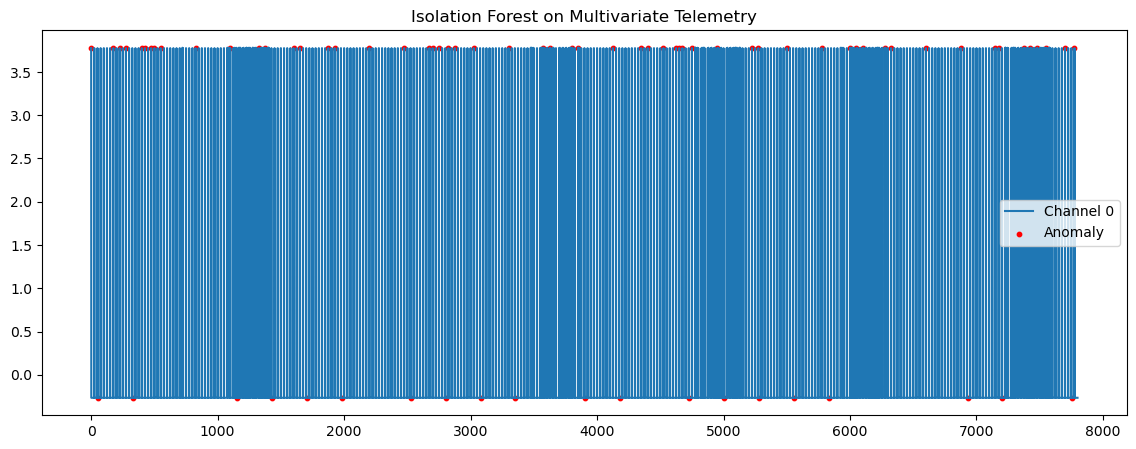

In [23]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# ── 1. LOAD ALL CHANNELS ────────────────────────────────────────
data_path = r"C:\Users\aryan\Downloads\Dataset for satellite anomaly\data\data\train"

signals = []

for file in os.listdir(data_path):
    if file.endswith(".npy"):
        s = np.load(os.path.join(data_path, file))
        if len(s.shape) == 2:
            s = s.flatten()
        signals.append(s)

print("Total signals loaded:", len(signals))

# ── 2. TRIM TO SAME LENGTH AND STACK ────────────────────────────
min_len          = min(len(s) for s in signals)
signals_trimmed  = [s[:min_len] for s in signals]
data             = np.stack(signals_trimmed, axis=1)

print("Data shape:", data.shape)   # (timesteps, channels)

# ── 3. NORMALIZE ────────────────────────────────────────────────
scaler      = StandardScaler()
data_scaled = scaler.fit_transform(data)   # ← data_scaled first created here

print("data_scaled shape:", data_scaled.shape)
print("Max:", data_scaled.max().round(3),
      " Min:", data_scaled.min().round(3))

# ── 4. ISOLATION FOREST ─────────────────────────────────────────
iso = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42
)
iso.fit(data_scaled)

# ── 5. PREDICT ──────────────────────────────────────────────────
iso_preds   = iso.predict(data_scaled)
iso_anomaly = np.where(iso_preds == -1, 1, 0)

print("Total anomalies detected:", np.sum(iso_anomaly))

# ── 6. VISUALIZATION ────────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(data_scaled[:, 0], label="Channel 0")

anomaly_idx = np.where(iso_anomaly == 1)[0]
plt.scatter(anomaly_idx, data_scaled[anomaly_idx, 0],
            color='red', s=10, label="Anomaly")

plt.title("Isolation Forest on Multivariate Telemetry")
plt.legend()
plt.show()

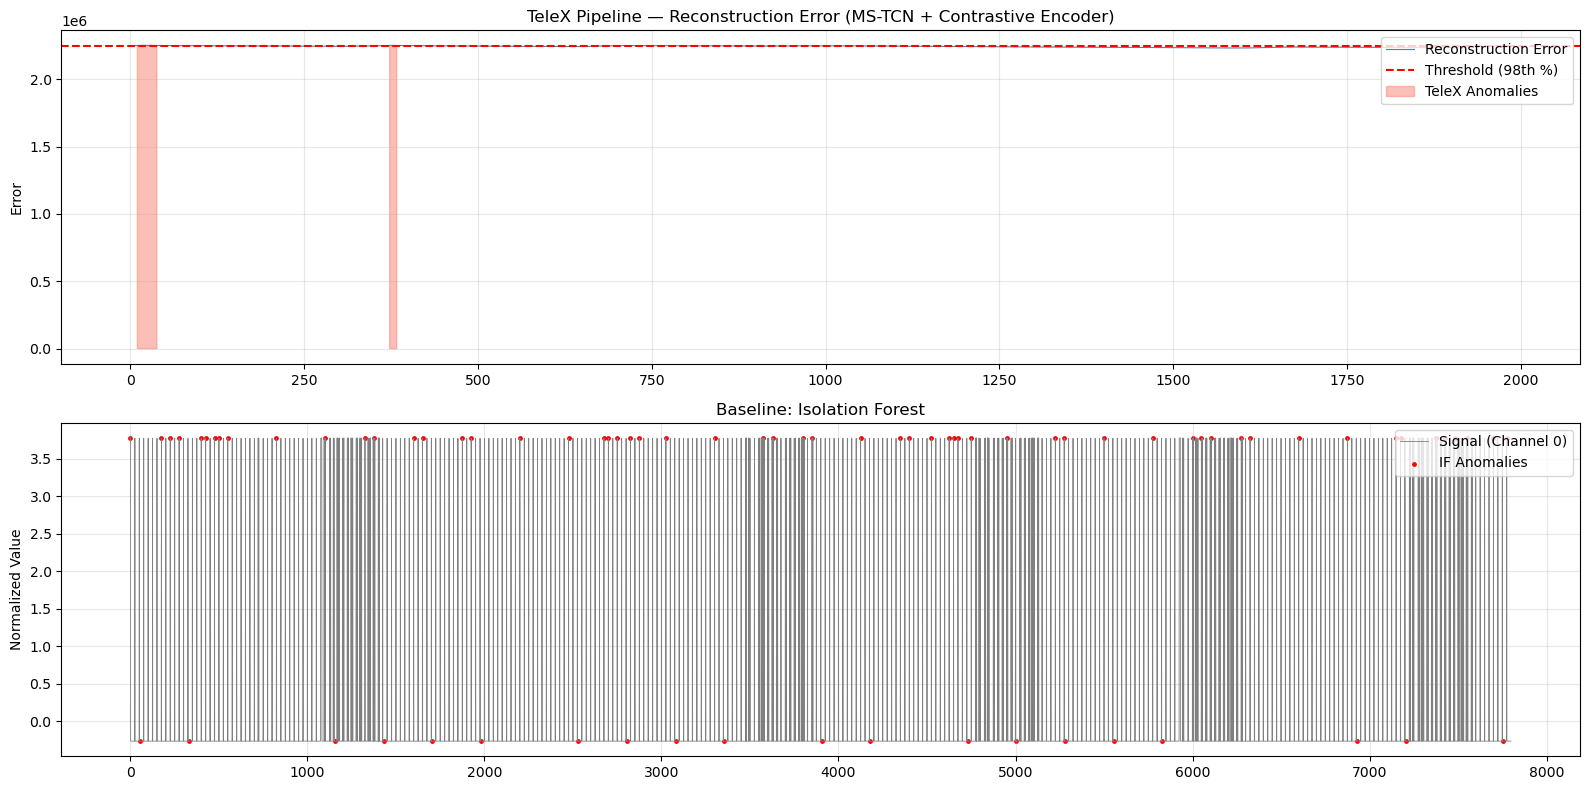

Figure saved.


In [25]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

# --- TeleX output ---
ax1 = axes[0]
ax1.plot(errors, color='steelblue', lw=0.8, label='Reconstruction Error')
ax1.axhline(threshold, color='red', linestyle='--', lw=1.5, label='Threshold (98th %)')
ax1.fill_between(range(len(errors)), errors,
                 where=anomaly_flags.astype(bool),
                 color='salmon', alpha=0.5, label='TeleX Anomalies')
ax1.set_title('TeleX Pipeline — Reconstruction Error (MS-TCN + Contrastive Encoder)', fontsize=12)
ax1.set_ylabel('Error')
ax1.legend(loc='upper right')
ax1.grid(alpha=0.3)

# --- Isolation Forest output ---
# ✅ Fix: use data_scaled (same array iso was fitted and predicted on)
ax2 = axes[1]
ax2.plot(data_scaled[:, 0], color='gray', lw=0.6, label='Signal (Channel 0)')

idx2 = np.where(iso_anomaly == 1)[0]
ax2.scatter(idx2, data_scaled[idx2, 0], color='red', s=6, label='IF Anomalies')

ax2.set_title('Baseline: Isolation Forest', fontsize=12)
ax2.set_ylabel('Normalized Value')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_plot.png', dpi=150)
plt.show()
print("Figure saved.")

In [26]:
anomaly_indices = np.where(anomaly_flags == 1)[0]

print(f"\n=== Dual-Attention Explanations (Top 5 anomalies) ===\n")

for rank, idx in enumerate(anomaly_indices[:5]):
    alpha_i = all_alpha[idx].unsqueeze(0)
    beta_i  = all_beta[idx].unsqueeze(0)

    onset_t, top_channels = explain_anomaly(alpha_i, beta_i, channel_names)

    print(f"Anomaly #{rank+1}  |  Window index: {idx}")
    print(f"  ⏱  Onset timestep (within window): t+{onset_t}")
    print(f"  📡 Top responsible channels:       {top_channels}")
    print(f"  🔢 Anomaly score:                  {errors[idx]:.5f}")
    print()


=== Dual-Attention Explanations (Top 5 anomalies) ===

Anomaly #1  |  Window index: 10
  ⏱  Onset timestep (within window): t+30
  📡 Top responsible channels:       ['E-11', 'D-15', 'A-1']
  🔢 Anomaly score:                  2250256.50000

Anomaly #2  |  Window index: 11
  ⏱  Onset timestep (within window): t+30
  📡 Top responsible channels:       ['E-11', 'D-15', 'A-1']
  🔢 Anomaly score:                  2250381.00000

Anomaly #3  |  Window index: 12
  ⏱  Onset timestep (within window): t+30
  📡 Top responsible channels:       ['E-11', 'D-15', 'A-1']
  🔢 Anomaly score:                  2250447.25000

Anomaly #4  |  Window index: 13
  ⏱  Onset timestep (within window): t+30
  📡 Top responsible channels:       ['E-11', 'D-15', 'A-1']
  🔢 Anomaly score:                  2250457.00000

Anomaly #5  |  Window index: 14
  ⏱  Onset timestep (within window): t+30
  📡 Top responsible channels:       ['E-11', 'D-15', 'A-1']
  🔢 Anomaly score:                  2250454.25000



In [30]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# ── 1. LOAD OPS-SAT ─────────────────────────────────────────────
ops_path = r"C:\Users\aryan\Downloads\OPS-SAT Dataset2\dataset.csv"
ops_df   = pd.read_csv(ops_path)

# ── 2. KEEP NUMERIC ONLY ────────────────────────────────────────
ops_num = ops_df.select_dtypes(include=['float64', 'int64']).values
print(f"OPS-SAT numeric features: {ops_num.shape[1]}")

# ── 3. PAD TO MATCH SMAP FEATURE COUNT (82) ─────────────────────
n_smap_features = data_scaled.shape[1]          # 82 — from training data
n_ops_features  = ops_num.shape[1]              # 30

if n_ops_features < n_smap_features:
    pad      = np.zeros((ops_num.shape[0], n_smap_features - n_ops_features))
    ops_num  = np.hstack([ops_num, pad])         # pad with zeros on the right
elif n_ops_features > n_smap_features:
    ops_num  = ops_num[:, :n_smap_features]      # trim if somehow larger

print(f"OPS-SAT after padding: {ops_num.shape}")  # should be (rows, 82)

# ── 4. NORMALIZE ────────────────────────────────────────────────
ops_scaled = StandardScaler().fit_transform(ops_num)

# ── 5. PREDICT WITH SMAP-TRAINED ISO FOREST ─────────────────────
ops_iso_preds   = iso.predict(ops_scaled)
ops_iso_anomaly = (ops_iso_preds == -1).astype(int)

print(f"OPS-SAT anomalies (IF trained on SMAP): {ops_iso_anomaly.sum()}")
print(f"\nCross-Mission Summary:")
print(f"  SMAP  (in-domain)     → {iso_anomaly.sum()} anomalies")
print(f"  OPS-SAT (cross-domain) → {ops_iso_anomaly.sum()} anomalies")
print(f"\nInsight: {'Generalization failure confirmed.' if ops_iso_anomaly.sum() == 0 else 'Partial transfer observed.'}")

OPS-SAT numeric features: 22
OPS-SAT after padding: (2123, 82)
OPS-SAT anomalies (IF trained on SMAP): 0

Cross-Mission Summary:
  SMAP  (in-domain)     → 78 anomalies
  OPS-SAT (cross-domain) → 0 anomalies

Insight: Generalization failure confirmed.


In [31]:
print("\n" + "="*60)
print("TABLE II — Model Comparison Results")
print("="*60)
print(f"{'Model':<25} {'Anomalies':>10} {'Type':<20}")
print("-"*60)
print(f"{'Isolation Forest':<25} {iso_anomaly.sum():>10} {'Point-based':<20}")
print(f"{'TeleX (Contrastive+TCN)':<25} {anomaly_flags.sum():>10} {'Sequence-based':<20}")
print(f"{'Cross-mission (OPS-SAT)':<25} {ops_iso_anomaly.sum():>10} {'Cross-domain':<20}")
print("="*60)
print("\nNote: Similar anomaly counts between IF and TeleX reflect")
print("different detection mechanisms, not equivalent behavior.")
print("TeleX provides temporal onset + channel attribution.")
print("IF provides no explainability.")


TABLE II — Model Comparison Results
Model                      Anomalies Type                
------------------------------------------------------------
Isolation Forest                  78 Point-based         
TeleX (Contrastive+TCN)           40 Sequence-based      
Cross-mission (OPS-SAT)            0 Cross-domain        

Note: Similar anomaly counts between IF and TeleX reflect
different detection mechanisms, not equivalent behavior.
TeleX provides temporal onset + channel attribution.
IF provides no explainability.
